# Unlearning Codebook-Only Model Benchmark



In [ ]:
# Optional: install/update dependencies once.
%pip install -q -U openpyxl tqdm python-dotenv tiktoken openai anthropic google-genai pydantic


## 1. API keys and configuration



In [ ]:
import os

try:
    from google.colab import userdata

    for env_name in ["OPENAI_API_KEY", "ANTHROPIC_API_KEY", "GEMINI_API_KEY"]:
        value = userdata.get(env_name)
        if value:
            os.environ[env_name] = value

    print("Loaded available API keys from Colab userdata.")
except ImportError:
    print(
        "Not running in Google Colab. "
        "Set OPENAI_API_KEY, ANTHROPIC_API_KEY, and GEMINI_API_KEY in the environment."
    )


Loaded available API keys from Colab userdata.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone

import os
import re
import json
import time
import math
import hashlib
from collections import defaultdict
from typing import Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display
from pydantic import BaseModel, ConfigDict, Field, ValidationError

from dotenv import load_dotenv


from tqdm.auto import tqdm

load_dotenv(dotenv_path=Path(".env"))

# Exact workbook supplied for this definitions-only pipeline.
WORKBOOK_PATH = Path("/content/Unlearning_Codebook_Combined_Human_Test_Set.xlsx")
CODEBOOK_SHEET = "Codebook"
TEST_SHEET = "GPT Test"


OUTPUT_DIR = Path("outputs_unlearning_definitions_only_v5")
OUTPUT_DIR.mkdir(exist_ok=True)

# New version prevents old four-prompt results from being resumed into this experiment.
PROMPT_VERSION = "v5_definitions_only_combined_human_test"

# Provider-specific execution switches. Each provider has its own run cell later.
RUN_OPENAI_CALLS = True
RUN_ANTHROPIC_CALLS = True
RUN_GEMINI_CALLS = True

# Stop after the first final API/configuration error for a provider.
# Transient errors still use retry logic before becoming final errors.
STOP_PROVIDER_ON_FIRST_ERROR = True

# Set to an integer for quick testing; None uses the complete GPT Test sheet.
ROW_LIMIT = None

# Optional paragraph truncation. None preserves the complete paragraph.
MAX_TEXT_CHARS = None

# Output/API settings.
MAX_OUTPUT_TOKENS = 2048
REQUEST_SLEEP_SECONDS = 0.2
RESUME_FROM_JSONL = True

# Hard preflight budget guard PER PROVIDER.
MAX_ESTIMATED_COST_USD_PER_PROVIDER = 5.00

# Model and pricing settings retained from the attached notebook.
MODEL_CONFIG = [
    {
        "provider": "openai",
        "model": "gpt-5.6-terra",
        "enabled": True,
        "api_key_env": "OPENAI_API_KEY",
        "input_usd_per_1m": 0.20,
        "output_usd_per_1m": 1.25,
        "reasoning_effort": "low",
        "request_sleep_seconds": 0.2,
    },
    {
        "provider": "anthropic",
        "model": "claude-sonnet-5",
        "enabled": True,
        "api_key_env": "ANTHROPIC_API_KEY",
        "input_usd_per_1m": 2.00,
        "output_usd_per_1m": 10.00,
        "effort": "low",
        "request_sleep_seconds": 0.2,
    },
    {
        "provider": "gemini",
        "model": "gemini-3.1-flash-lite",
        "enabled": True,
        "api_key_env": "GEMINI_API_KEY",
        "input_usd_per_1m": 0.75,
        "output_usd_per_1m": 4.50,
        "thinking_level": "minimal",
        "request_sleep_seconds": 0.5,
    },
]

# This version intentionally has exactly one prompt condition for every provider.
PROMPT_VARIANTS_TO_RUN = ["definitions_only"]

print("Workbook path:", WORKBOOK_PATH)
print("Test sheet:", TEST_SHEET)
print("Codebook sheet:", CODEBOOK_SHEET)
print("Prompt version:", PROMPT_VERSION)
print("Prompt variants:", PROMPT_VARIANTS_TO_RUN)
print("Output folder:", OUTPUT_DIR.resolve())
print("Provider run switches:", {
    "openai": RUN_OPENAI_CALLS,
    "anthropic": RUN_ANTHROPIC_CALLS,
    "gemini": RUN_GEMINI_CALLS,
})


Workbook path: /content/Unlearning_Codebook_Combined_Human_Test_Set.xlsx
Test sheet: GPT Test
Codebook sheet: Codebook
Prompt version: v5_definitions_only_combined_human_test
Prompt variants: ['definitions_only']
Output folder: /content/outputs_unlearning_definitions_only_v5
Provider run switches: {'openai': True, 'anthropic': True, 'gemini': True}


## 2. Load `GPT Test` and `Codebook`


In [ ]:
def drop_empty_unnamed_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.dropna(axis=1, how="all")
    df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed", na=False)]
    return df


if not WORKBOOK_PATH.exists():
    raise FileNotFoundError(
        f"Workbook not found: {WORKBOOK_PATH}. "
        "Upload the workbook to Colab or update WORKBOOK_PATH."
    )

test_df = drop_empty_unnamed_columns(
    pd.read_excel(WORKBOOK_PATH, sheet_name=TEST_SHEET)
)
raw_codebook_df = pd.read_excel(
    WORKBOOK_PATH,
    sheet_name=CODEBOOK_SHEET,
    header=None,
)

required_test_cols = {"Number", "Text Content", "Unlearning"}
missing_test_cols = required_test_cols - set(test_df.columns)
if missing_test_cols:
    raise ValueError(
        f"{TEST_SHEET!r} is missing required columns: "
        + ", ".join(sorted(missing_test_cols))
    )

for optional_col in ["Document", "Target", "Government Agency", "Rationale", "Codes"]:
    if optional_col not in test_df.columns:
        test_df[optional_col] = ""

# The first row may contain an objective. The true table header is the row where column A == "Code".
header_candidates = raw_codebook_df.index[
    raw_codebook_df.iloc[:, 0].astype(str).str.strip().str.lower().eq("code")
].tolist()
if not header_candidates:
    raise ValueError(
        f"Could not find the codebook table header row in sheet {CODEBOOK_SHEET!r}; "
        "expected a row where column A equals 'Code'."
    )

codebook_header_row = header_candidates[0]
codebook_df = raw_codebook_df.iloc[codebook_header_row + 1:].copy()
codebook_df.columns = [
    str(x).strip() if not pd.isna(x) else ""
    for x in raw_codebook_df.iloc[codebook_header_row].tolist()
]
codebook_df = codebook_df.dropna(axis=0, how="all")
codebook_df = codebook_df.loc[:, [c for c in codebook_df.columns if c != ""]]
codebook_df = codebook_df.reset_index(drop=True)

required_codebook_cols = {
    "Code",
    "Definition",
    "Detection Logic",
    "Examples",
    "Positive Clarification",
    "Negative Clarification",
}
missing_codebook_cols = required_codebook_cols - set(codebook_df.columns)
if missing_codebook_cols:
    raise ValueError(
        "The definitions-only prompt requires these codebook columns, but they are missing: "
        + ", ".join(sorted(missing_codebook_cols))
    )

print("GPT Test shape before label cleaning:", test_df.shape)
print("Codebook table shape:", codebook_df.shape)
print("GPT Test columns:", list(test_df.columns))
print("Codebook columns:", list(codebook_df.columns))

display(test_df.head(5))
display(codebook_df.head(8))


GPT Test shape before label cleaning: (49, 8)
Codebook table shape: (14, 6)
GPT Test columns: ['Number', 'Text Content', 'Document', 'Codes', 'Unlearning', 'Target', 'Government Agency', 'Rationale']
Codebook columns: ['Code', 'Definition', 'Detection Logic', 'Examples', 'Positive Clarification', 'Negative Clarification']


,Number,Text Content,Document,Codes,Unlearning,Target,Government Agency,Rationale
0,ICA25:1:1,"Coordination within EPA, with State and local ...",EPA,Unlearning: No,No,NaN,NaN,Not unlearning. As no logic being abandoned.
1,ICA25:1:2,"EPA officials told us that, in some instances,...",EPA,Unlearning: No,No,NaN,NaN,Not unlearning. As no logic being abandoned ju...
2,ICA25:1:3,"From our review of wastewater issues, we found...",EPA,Unlearning: Yes | Government Agency: EPA,Yes,NaN,EPA,Unlearning as it states EPA was not commuunica...
3,ICA25:1:4,Communication is a key component of emergency ...,EPA,Unlearning: Yes | Government Agency: EPA,Yes,NaN,EPA,Unlearning as it focuses on establishing teams...
4,ICA25:1:5,EPA regional officials concurred that tremendo...,EPA,Unlearning: Yes | Government Agency: EPA,Yes,NaN,EPA,"Unlearning as they intend to ""reevaluate"" curr..."


,Code,Definition,Detection Logic,Examples,Positive Clarification,Negative Clarification
0,Step 1 -- Binary classification based on unlea...,NaN,NaN,NaN,NaN,NaN
1,Unlearning (Yes/No),Unlearning is the deliberate process by which ...,Does the text explicitly identify a prior poli...,"""[T]he Federal government should not rely on t...",Code when the text:\n• Names a specific prior ...,DO NOT code if:\n• The text only documents wha...
2,STEP 2 — TARGET OF UNLEARNING (assign one per ...,NaN,NaN,NaN,NaN,NaN
3,Target (Leadership),"The text questions or redefines the role, auth...",Does the text call for redefining or redistrib...,"""[A] single individual directly responsible an...",Code when the text:\n • Calls into question wh...,DO NOT code if:\n • The text recommends appoin...
4,"Target (laws, plans and policies)","The text calls for terminating, replacing, or ...","Does the text identify a specific law, plan, o...","""Removing statutory restrictions on DOD author...",Code when the text:\n • Calls for eliminating ...,DO NOT code if:\n • The text proposes reform o...
5,Target (capabilities),The text identifies a technical system — model...,Does the text identify a specific technical sy...,"""We identified the need for the federal govern...",Code when the text:\n • Identifies a technical...,DO NOT code if:\n • The text describes routine...
6,Target (funds and resource allocation),The text calls for changing how disaster funds...,Does the text identify the existing funds mana...,"""Federal agencies involved in managing interna...",Code when the text:\n • Calls for changing the...,DO NOT code if:\n • The text only requests add...
7,"Target (misclleanous) organizational culture, ...",The text calls for unlearning in a domain not ...,Does the text call for discarding a prior assu...,Use sparingly. Flag for team discussion if use...,Code when the text:\n • Explicitly rejects a p...,DO NOT use as a default catch-all. If the pass...


## 3. Clean human labels

This section only normalizes the explicit revised workbook fields. It does not parse or recreate Pillar, Depth, Nature, or any other legacy dimensions, and it does not remove additional duplicate paragraphs.

In [ ]:
def normalize_yes_no(value):
    """Normalize yes/no-like values to 'Yes', 'No', or np.nan."""
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    if s in {"yes", "y", "true", "1", "unlearning"}:
        return "Yes"
    if s in {"no", "n", "false", "0", "not unlearning", "non-unlearning"}:
        return "No"
    if s.startswith("yes"):
        return "Yes"
    if s.startswith("no"):
        return "No"
    return np.nan


def clean_text_for_prompt(text, max_chars=MAX_TEXT_CHARS):
    if pd.isna(text):
        return ""
    s = re.sub(r"\s+", " ", str(text)).strip()
    if max_chars is not None and len(s) > max_chars:
        s = s[:max_chars].rstrip() + " ... [TRUNCATED]"
    return s


test_df["ground_truth_unlearning"] = test_df["Unlearning"].apply(normalize_yes_no)
test_df["ground_truth_target"] = test_df["Target"].fillna("").astype(str).str.strip()
test_df["ground_truth_agency"] = (
    test_df["Government Agency"].fillna("").astype(str).str.strip()
)

invalid_label_rows = test_df[
    test_df["Text Content"].isna()
    | test_df["ground_truth_unlearning"].isna()
].copy()

if not invalid_label_rows.empty:
    print(
        f"Dropping {len(invalid_label_rows)} rows with missing text or invalid "
        "explicit Unlearning ground truth."
    )
    display(invalid_label_rows[["Number", "Text Content", "Unlearning"]])

test_df = test_df.dropna(
    subset=["Text Content", "ground_truth_unlearning"]
).reset_index(drop=True)

if ROW_LIMIT is not None:
    test_df = test_df.head(ROW_LIMIT).copy()

normalized_text = (
    test_df["Text Content"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.lower()
)
exact_duplicate_count = int(normalized_text.duplicated(keep=False).sum())

print("Clean test rows:", len(test_df))
print("Ground-truth distribution:")
display(
    test_df["ground_truth_unlearning"]
    .value_counts(dropna=False)
    .rename_axis("Unlearning")
    .reset_index(name="n")
)
print("Rows with human Target labels:", int(test_df["ground_truth_target"].ne("").sum()))
print("Rows with human Government Agency labels:", int(test_df["ground_truth_agency"].ne("").sum()))
print("Rows participating in exact normalized-text duplicate groups:", exact_duplicate_count)

display(
    test_df[
        [
            "Number",
            "Document",
            "ground_truth_unlearning",
            "ground_truth_target",
            "ground_truth_agency",
        ]
    ].head(10)
)


Clean test rows: 49
Ground-truth distribution:


,Unlearning,n
0,Yes,39
1,No,10


Rows with human Target labels: 8
Rows with human Government Agency labels: 21
Rows participating in exact normalized-text duplicate groups: 0


,Number,Document,ground_truth_unlearning,ground_truth_target,ground_truth_agency
0,ICA25:1:1,EPA,No,,
1,ICA25:1:2,EPA,No,,
2,ICA25:1:3,EPA,Yes,,EPA
3,ICA25:1:4,EPA,Yes,,EPA
4,ICA25:1:5,EPA,Yes,,EPA
5,ICA25:1:6,EPA,Yes,,
6,ICA25:1:9,EPA,No,,
7,ICA25:1:10,EPA,Yes,,EPA; EPA region 6; USACE
8,ICA25:1:11,EPA,Yes,,EPA
9,ICA25:1:12,EPA,Yes,,USACE


## 4. Serialize the codebook

The definitions-only prompt includes the same six codebook fields for every code row, including the codebook's own `Examples` column.

In [ ]:
def _prompt_value(value) -> str:
    if pd.isna(value):
        return ""
    return clean_text_for_prompt(value, max_chars=None)


def make_codebook_text(codebook: pd.DataFrame) -> str:
    """Serialize the same six codebook fields into every definitions-only prompt."""
    parts = []

    for _, row in codebook.iterrows():
        code_name = _prompt_value(row.get("Code", ""))
        if not code_name or code_name.lower() == "nan":
            continue

        block = [
            f"Code: {code_name}",
            f"Definition: {_prompt_value(row.get('Definition', ''))}",
            f"Detection logic: {_prompt_value(row.get('Detection Logic', ''))}",
            f"Examples: {_prompt_value(row.get('Examples', ''))}",
            f"Positive: {_prompt_value(row.get('Positive Clarification', ''))}",
            f"Negative: {_prompt_value(row.get('Negative Clarification', ''))}",
        ]
        parts.append("\n".join(block))

    return "\n\n".join(parts)


CODEBOOK_TEXT = make_codebook_text(codebook_df)

nonempty_codebook_examples = [
    _prompt_value(v)
    for v in codebook_df["Examples"]
    if not pd.isna(v) and str(v).strip()
]

assert "Examples:" in CODEBOOK_TEXT, (
    "The codebook's own Examples field is missing from CODEBOOK_TEXT."
)
if nonempty_codebook_examples:
    assert nonempty_codebook_examples[0] in CODEBOOK_TEXT, (
        "A codebook example was not preserved."
    )

print("Codebook context characters:", len(CODEBOOK_TEXT))
print("Codebook rows serialized:", CODEBOOK_TEXT.count("Code: "))


Codebook context characters: 10701
Codebook rows serialized: 14


## 5. Definitions-only prompt

All three providers receive the same semantic task, the same serialized codebook, the same output schema, and the same paragraph text. This notebook intentionally exposes no other prompt condition.

In [ ]:
BASE_SYSTEM_PROMPT = "Return valid JSON only. Do not include markdown."

COMMON_TASK_BLOCK = """You are coding federal disaster policy text using the unlearning codebook.

Task:
1. Decide whether the paragraph contains unlearning.
2. If yes, assign one target type.
3. Identify the agency or sub-unit if the paragraph states one.
4. Keep the rationale short.""".strip()

JSON_SCHEMA_NOTE = """
Return valid JSON only with this structure:
{
  "unlearning_present": true/false,
  "target_type": "Leadership | laws_plans_policies | capabilities | funds_resources | misc_organizational | none",
  "agency": "agency or sub-unit name if stated, otherwise null",
  "confidence": "number from 0.0 to 1.0",
  "rationale": "one short sentence"
}
""".strip()


class AnnotationOutput(BaseModel):
    model_config = ConfigDict(extra="forbid")

    unlearning_present: bool
    target_type: Literal[
        "Leadership",
        "laws_plans_policies",
        "capabilities",
        "funds_resources",
        "misc_organizational",
        "none",
    ]
    agency: str | None
    confidence: float = Field(
        ge=0.0,
        le=1.0,
        description="Model's confidence in the classification, from 0.0 to 1.0.",
    )
    rationale: str


ANNOTATION_JSON_SCHEMA = AnnotationOutput.model_json_schema()


def build_user_prompt(variant_name: str, test_row: pd.Series) -> str:
    if variant_name != "definitions_only":
        raise ValueError(
            f"This notebook supports only 'definitions_only'; received {variant_name!r}."
        )

    text = clean_text_for_prompt(
        test_row["Text Content"],
        max_chars=MAX_TEXT_CHARS,
    )
    paragraph_id = test_row.get("Number", test_row.name)

    return f"""{COMMON_TASK_BLOCK}

Codebook:
{CODEBOOK_TEXT}

{JSON_SCHEMA_NOTE}

Paragraph ID: {paragraph_id}
Paragraph:
{text}""".strip()


def build_prompt_messages(variant_name: str, test_row: pd.Series) -> list[dict]:
    return [
        {"role": "system", "content": BASE_SYSTEM_PROMPT},
        {"role": "user", "content": build_user_prompt(variant_name, test_row)},
    ]


def prompt_sha256(messages: list[dict]) -> str:
    canonical = json.dumps(
        messages,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )
    return hashlib.sha256(canonical.encode("utf-8")).hexdigest()


assert PROMPT_VARIANTS_TO_RUN == ["definitions_only"]
assert "confidence" in AnnotationOutput.model_fields
assert "confidence" in ANNOTATION_JSON_SCHEMA.get("properties", {})

preview_row = test_df.iloc[0]
preview_messages = build_prompt_messages("definitions_only", preview_row)
preview_user_prompt = preview_messages[1]["content"]

assert "Codebook:" in preview_user_prompt
assert "Labeled examples:" not in preview_user_prompt

prompt_audit_df = pd.DataFrame([
    {
        "prompt_version": PROMPT_VERSION,
        "prompt_variant": "definitions_only",
        "system_prompt": preview_messages[0]["content"],
        "prompt_sha256_first_row": prompt_sha256(preview_messages),
        "user_prompt_chars_first_row": len(preview_user_prompt),
        "contains_codebook": "Codebook:" in preview_user_prompt,
        "contains_codebook_examples_field": "Examples:" in preview_user_prompt,
        "contains_labeled_examples": "Labeled examples:" in preview_user_prompt,
        "requires_confidence": '"confidence"' in preview_user_prompt,
    }
])

print("Definitions-only prompt/schema assertions: PASSED")
display(prompt_audit_df)

print("=" * 100)
print("PROMPT VARIANT: definitions_only")
print("PROMPT SHA256:", prompt_sha256(preview_messages))
print(preview_user_prompt[:5000])
print("...\n")


Definitions-only prompt/schema assertions: PASSED


,prompt_version,prompt_variant,system_prompt,prompt_sha256_first_row,user_prompt_chars_first_row,contains_codebook,contains_codebook_examples_field,contains_labeled_examples,requires_confidence
0,v5_definitions_only_combined_human_test,definitions_only,Return valid JSON only. Do not include markdown.,173c98c096ffbb9ccad68d127321ba3f408540a302cb8f...,11725,True,True,False,True


PROMPT VARIANT: definitions_only
PROMPT SHA256: 173c98c096ffbb9ccad68d127321ba3f408540a302cb8f59d817b23aaa1dc2cb
You are coding federal disaster policy text using the unlearning codebook.

Task:
1. Decide whether the paragraph contains unlearning.
2. If yes, assign one target type.
3. Identify the agency or sub-unit if the paragraph states one.
4. Keep the rationale short.

Codebook:
Code: Step 1 -- Binary classification based on unlearning definition
Definition: 
Detection logic: 
Examples: 
Positive: 
Negative: 

Code: Unlearning (Yes/No)
Definition: Unlearning is the deliberate process by which a government agency discards misaligned assumptions, obsolete knowledge, or outdated routines in response to demonstrated failure — here, Hurricane Katrina. It becomes visible in discourse when institutions explicitly problematise a prior practice, justify its abandonment, and signal a departure from established norms.
Detection logic: Does the text explicitly identify a prior policy, assumpt

## 6. Token and cost estimation

In [ ]:
def estimate_tokens_text(text: str, provider: str = "generic") -> int:
    """Best-effort token estimate for preflight budgeting."""
    if text is None:
        return 0
    text = str(text)

    if provider == "openai":
        try:
            import tiktoken

            enc = tiktoken.get_encoding("cl100k_base")
            return len(enc.encode(text))
        except Exception:
            pass

    return max(1, math.ceil(len(text) / 4))


def estimate_messages_tokens(messages: list[dict], provider: str = "generic") -> int:
    return (
        sum(
            estimate_tokens_text(m.get("content", ""), provider) + 6
            for m in messages
        )
        + 10
    )


def cost_from_tokens(input_tokens: int, output_tokens: int, cfg: dict) -> float:
    return (
        (input_tokens / 1_000_000) * cfg["input_usd_per_1m"]
        + (output_tokens / 1_000_000) * cfg["output_usd_per_1m"]
    )


def model_effort_descriptor(cfg: dict) -> str:
    if cfg["provider"] == "openai":
        return f"reasoning_effort={cfg.get('reasoning_effort', 'none')}"

    if cfg["provider"] == "anthropic":
        if cfg.get("effort") is not None:
            return f"effort={cfg['effort']}"
        return "effort=omitted"

    if cfg["provider"] == "gemini":
        return f"thinking_level={cfg.get('thinking_level', 'low')}"

    return "default"


def active_model_configs(require_api_key: bool = False) -> list[dict]:
    active = []

    for cfg in MODEL_CONFIG:
        if not cfg.get("enabled", True):
            continue

        key_present = bool(os.getenv(cfg.get("api_key_env", "")))
        if require_api_key and not key_present:
            print(
                f"Skipping {cfg['provider']} / {cfg['model']} because "
                f"{cfg['api_key_env']} is not set."
            )
            continue

        active.append(cfg)

    return active


def estimate_full_grid(
    test_rows: pd.DataFrame,
    model_configs: list[dict],
    variants: list[str],
    assumed_output_tokens: int = 100,
) -> pd.DataFrame:
    rows = []

    for cfg in model_configs:
        for variant in variants:
            input_total = 0

            for _, row in test_rows.iterrows():
                messages = build_prompt_messages(variant, row)
                input_total += estimate_messages_tokens(
                    messages,
                    provider=cfg["provider"],
                )

            output_total = assumed_output_tokens * len(test_rows)

            rows.append({
                "provider": cfg["provider"],
                "model": cfg["model"],
                "model_effort": model_effort_descriptor(cfg),
                "prompt_version": PROMPT_VERSION,
                "prompt_variant": variant,
                "n_rows": len(test_rows),
                "estimated_input_tokens": int(input_total),
                "assumed_output_tokens": int(output_total),
                "estimated_total_tokens": int(input_total + output_total),
                "estimated_cost_usd": cost_from_tokens(
                    input_total,
                    output_total,
                    cfg,
                ),
            })

    return pd.DataFrame(rows)


estimate_df = estimate_full_grid(
    test_df,
    active_model_configs(require_api_key=False),
    PROMPT_VARIANTS_TO_RUN,
)
display(estimate_df)

provider_estimates = estimate_df.groupby(
    ["provider", "model", "model_effort"],
    as_index=False,
).agg(
    estimated_input_tokens=("estimated_input_tokens", "sum"),
    assumed_output_tokens=("assumed_output_tokens", "sum"),
    estimated_total_tokens=("estimated_total_tokens", "sum"),
    estimated_cost_usd=("estimated_cost_usd", "sum"),
)

display(provider_estimates)
print(
    "Estimated total cost across all enabled models: $",
    round(estimate_df["estimated_cost_usd"].sum(), 6),
)


,provider,model,model_effort,prompt_version,prompt_variant,n_rows,estimated_input_tokens,assumed_output_tokens,estimated_total_tokens,estimated_cost_usd
0,openai,gpt-5.6-terra,reasoning_effort=low,v5_definitions_only_combined_human_test,definitions_only,49,116447,4900,121347,0.029414
1,anthropic,claude-sonnet-5,effort=low,v5_definitions_only_combined_human_test,definitions_only,49,148584,4900,153484,0.346168
2,gemini,gemini-3.1-flash-lite,thinking_level=minimal,v5_definitions_only_combined_human_test,definitions_only,49,148584,4900,153484,0.133488


,provider,model,model_effort,estimated_input_tokens,assumed_output_tokens,estimated_total_tokens,estimated_cost_usd
0,anthropic,claude-sonnet-5,effort=low,148584,4900,153484,0.346168
1,gemini,gemini-3.1-flash-lite,thinking_level=minimal,148584,4900,153484,0.133488
2,openai,gpt-5.6-terra,reasoning_effort=low,116447,4900,121347,0.029414


Estimated total cost across all enabled models: $ 0.50907


## 7. Provider API wrappers

The working provider-specific structured-output wrappers from the attached notebook are retained. All wrappers return the same normalized usage/result contract.

In [ ]:
def extract_json_object(text: str) -> dict:
    """Parse a JSON object from a response, with a conservative fallback."""
    if isinstance(text, dict):
        return text
    s = str(text or "").strip()
    if not s:
        return {}

    try:
        parsed = json.loads(s)
        return parsed if isinstance(parsed, dict) else {}
    except json.JSONDecodeError:
        pass

    match = re.search(r"\{.*\}", s, flags=re.DOTALL)
    if not match:
        return {}

    try:
        parsed = json.loads(match.group(0))
        return parsed if isinstance(parsed, dict) else {}
    except json.JSONDecodeError:
        return {}


def normalize_model_prediction(parsed: dict, raw_text: str = ""):
    """Normalize the common structured output or conservative legacy fallbacks to Yes/No."""
    if isinstance(parsed, dict):
        if "unlearning_present" in parsed:
            return normalize_yes_no(parsed.get("unlearning_present"))

        for key in ["unlearning", "prediction", "label", "answer", "classification"]:
            if key in parsed:
                normalized = normalize_yes_no(parsed.get(key))
                if not pd.isna(normalized):
                    return normalized

    s = str(raw_text or "").strip()
    field_match = re.search(
        r'"?(?:unlearning_present|unlearning|label|prediction|answer|classification)"?\s*:\s*"?(yes|no|true|false)"?',
        s,
        flags=re.IGNORECASE,
    )
    if field_match:
        return normalize_yes_no(field_match.group(1))

    if len(s) < 200:
        yn_match = re.search(r"\b(yes|no)\b", s, flags=re.IGNORECASE)
        if yn_match:
            return normalize_yes_no(yn_match.group(1))

    return np.nan


def normalize_confidence(value):
    """Return a float in [0, 1], otherwise NaN."""
    try:
        number = float(value)
    except (TypeError, ValueError):
        return np.nan
    return number if 0.0 <= number <= 1.0 else np.nan


class APIErrorForRetry(Exception):
    pass


class NonRetryableQuotaError(RuntimeError):
    pass


class NonRetryableRequestError(RuntimeError):
    pass


def _retry_wait_from_error(error: Exception, default_wait: float) -> float:
    """Honor provider retry-delay hints such as retryDelay:'36s' or 'Please retry in 36.87s'."""
    text = str(error)
    patterns = [
        r"retryDelay[^0-9]*(\d+(?:\.\d+)?)s",
        r"Please retry in\s+(\d+(?:\.\d+)?)s",
        r"retry in\s+(\d+(?:\.\d+)?)\s*seconds?",
    ]
    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            return float(match.group(1)) + 1.0
    return default_wait


def _is_nonretryable_request_error(error: Exception) -> bool:
    """Do not waste retries on malformed payloads, deprecated parameters, or schema errors."""
    text = str(error).lower()
    request_markers = [
        "error code: 400",
        "400 invalid_argument",
        "invalid_request_error",
        "invalid json payload",
        "unknown name",
        "deprecated for this model",
        "cannot find field",
    ]
    return any(marker in text for marker in request_markers)


def retry_api_call(max_attempts=4, min_wait=5, max_wait=90):
    def decorator(fn):
        def wrapper(*args, **kwargs):
            last_error = None

            for attempt in range(max_attempts):
                try:
                    return fn(*args, **kwargs)

                except (
                    NonRetryableQuotaError,
                    NonRetryableRequestError,
                ):
                    raise

                except Exception as e:
                    last_error = e

                    # Malformed requests/configuration errors
                    # cannot be fixed by waiting.
                    if _is_nonretryable_request_error(e):
                        raise NonRetryableRequestError(
                            "Non-retryable API "
                            "request/configuration error in "
                            f"{fn.__name__}: {e}"
                        ) from e

                    # On paid Gemini, quota/rate-limit 429s are
                    # treated as transient and retried using the
                    # provider's retry-delay hint.
                    if attempt == max_attempts - 1:
                        raise

                    default_wait = min(
                        max_wait,
                        min_wait * (2 ** attempt),
                    )

                    wait_seconds = min(
                        max_wait,
                        _retry_wait_from_error(
                            e,
                            default_wait,
                        ),
                    )

                    print(
                        "Retrying after transient error from "
                        f"{fn.__name__}: {e}\n"
                        f"Waiting {wait_seconds:.1f}s..."
                    )

                    time.sleep(wait_seconds)

            raise last_error

        return wrapper

    return decorator


def _common_api_result(
    *,
    raw_response: str,
    input_tokens: int,
    output_tokens: int,
    total_tokens: int,
    latency_seconds: float,
    reasoning_tokens: int = 0,
) -> dict:
    return {
        "raw_response": str(raw_response or ""),
        "input_tokens": int(input_tokens or 0),
        "output_tokens": int(output_tokens or 0),
        "total_tokens": int(total_tokens or (input_tokens or 0) + (output_tokens or 0)),
        "latency_seconds": float(latency_seconds),
        "reasoning_tokens": int(reasoning_tokens or 0),
    }


@retry_api_call(max_attempts=3, min_wait=5, max_wait=45)
def call_openai(messages: list[dict], cfg: dict) -> dict:
    """OpenAI Responses API + Pydantic Structured Outputs + explicit reasoning effort."""
    from openai import OpenAI

    client = OpenAI(api_key=os.getenv(cfg["api_key_env"]))
    system_text = next((m["content"] for m in messages if m["role"] == "system"), "")
    response_input = [m for m in messages if m["role"] != "system"]

    start = time.time()
    response = client.responses.parse(
        model=cfg["model"],
        instructions=system_text,
        input=response_input,
        reasoning={"effort": cfg.get("reasoning_effort", "low")},
        max_output_tokens=MAX_OUTPUT_TOKENS,
        text_format=AnnotationOutput,
        store=False,
    )
    latency = time.time() - start

    parsed_obj = response.output_parsed
    if parsed_obj is None:
        raise APIErrorForRetry(
            f"OpenAI returned no parsed structured output. Raw output: {response.output_text!r}"
        )

    raw_text = json.dumps(parsed_obj.model_dump(), ensure_ascii=False)

    usage = getattr(response, "usage", None)
    input_tokens = getattr(usage, "input_tokens", 0) or 0
    output_tokens = getattr(usage, "output_tokens", 0) or 0
    total_tokens = getattr(usage, "total_tokens", 0) or input_tokens + output_tokens

    output_details = getattr(usage, "output_tokens_details", None)
    reasoning_tokens = getattr(output_details, "reasoning_tokens", 0) or 0

    return _common_api_result(
        raw_response=raw_text,
        input_tokens=input_tokens,
        output_tokens=output_tokens,
        total_tokens=total_tokens,
        latency_seconds=latency,
        reasoning_tokens=reasoning_tokens,
    )


@retry_api_call(max_attempts=3, min_wait=5, max_wait=45)
def call_anthropic(messages: list[dict], cfg: dict) -> dict:
    """Anthropic messages.parse() + Pydantic Structured Outputs; effort is sent only when configured."""
    from anthropic import Anthropic

    client = Anthropic(api_key=os.environ[cfg["api_key_env"]])

    system_text = "\n".join(
        m.get("content", "")
        for m in messages
        if m.get("role") == "system"
    ).strip()

    anthropic_messages = [
        {"role": m["role"], "content": m.get("content", "")}
        for m in messages
        if m.get("role") in {"user", "assistant"}
    ]


    start = time.time()

    anthropic_request = {
        "model": cfg["model"],
        "max_tokens": MAX_OUTPUT_TOKENS,
        "system": system_text,
        "messages": anthropic_messages,
        "output_format": AnnotationOutput,
    }

    # Sonnet 5 supports effort.
    # Haiku 4.5 does not.
    if cfg.get("effort") is not None:
        anthropic_request["output_config"] = {
            "effort": cfg["effort"]
        }

    response = client.messages.parse(
        **anthropic_request
    )

    latency = time.time() - start


    parsed_obj = response.parsed_output
    if parsed_obj is None:
        raise APIErrorForRetry("Anthropic returned no parsed structured output.")

    raw_text = json.dumps(parsed_obj.model_dump(), ensure_ascii=False)

    usage = getattr(response, "usage", None)
    input_tokens = getattr(usage, "input_tokens", 0) or 0
    output_tokens = getattr(usage, "output_tokens", 0) or 0

    return _common_api_result(
        raw_response=raw_text,
        input_tokens=input_tokens,
        output_tokens=output_tokens,
        total_tokens=input_tokens + output_tokens,
        latency_seconds=latency,
        reasoning_tokens=0,
    )


@retry_api_call(max_attempts=4, min_wait=8, max_wait=120)
def call_gemini(messages: list[dict], cfg: dict) -> dict:
    """Gemini generateContent + native raw JSON Schema + configured thinking level."""
    from google import genai
    from google.genai import types

    client = genai.Client(api_key=os.getenv(cfg["api_key_env"]))
    system_text = next((m["content"] for m in messages if m["role"] == "system"), "")
    user_text = "\n\n".join(
        m["content"]
        for m in messages
        if m["role"] == "user"
    )

    start = time.time()
    response = client.models.generate_content(
        model=cfg["model"],
        contents=user_text,
        config=types.GenerateContentConfig(
            system_instruction=system_text,
            max_output_tokens=MAX_OUTPUT_TOKENS,
            response_mime_type="application/json",
            # response_json_schema sends raw JSON Schema. Do NOT use response_schema with model_json_schema().
            response_json_schema=ANNOTATION_JSON_SCHEMA,
            thinking_config=types.ThinkingConfig(
                thinking_level=cfg.get("thinking_level", "low")
            ),
        ),
    )
    latency = time.time() - start


    raw_text = response.text or ""

    # Diagnose why Gemini stopped generating.
    finish_reason = None
    if getattr(response, "candidates", None):
        finish_reason = getattr(response.candidates[0], "finish_reason", None)

    finish_reason_text = str(finish_reason or "")

    if "MAX_TOKENS" in finish_reason_text.upper():
        raise NonRetryableRequestError(
            "Gemini output was truncated because max_output_tokens was reached. "
            f"finish_reason={finish_reason_text}. "
            f"Raw partial response: {raw_text!r}"
        )

    try:
        parsed_obj = AnnotationOutput.model_validate_json(raw_text)
    except ValidationError as e:
        raise APIErrorForRetry(
            "Gemini returned complete-looking output that failed "
            f"AnnotationOutput validation: {e}. "
            f"finish_reason={finish_reason_text}. "
            f"Raw: {raw_text!r}"
        ) from e


    raw_text = json.dumps(parsed_obj.model_dump(), ensure_ascii=False)

    usage = getattr(response, "usage_metadata", None)
    input_tokens = getattr(usage, "prompt_token_count", 0) or 0
    output_tokens = getattr(usage, "candidates_token_count", 0) or 0
    total_tokens = getattr(usage, "total_token_count", 0) or input_tokens + output_tokens
    thinking_tokens = getattr(usage, "thoughts_token_count", 0) or 0

    return _common_api_result(
        raw_response=raw_text,
        input_tokens=input_tokens,
        output_tokens=output_tokens,
        total_tokens=total_tokens,
        latency_seconds=latency,
        reasoning_tokens=thinking_tokens,
    )


def call_model(messages: list[dict], cfg: dict) -> dict:
    provider = cfg["provider"].lower()
    if provider == "openai":
        return call_openai(messages, cfg)
    if provider == "anthropic":
        return call_anthropic(messages, cfg)
    if provider == "gemini":
        return call_gemini(messages, cfg)
    raise ValueError(f"Unsupported provider: {provider}")


## 8. Provider-separated execution

Each provider has its own JSONL resume log, CSV snapshot, preflight estimate, and diagnostics. Because this notebook has only one prompt condition, each provider makes at most one call per retained GPT Test row.

In [ ]:
def get_provider_config(provider: str) -> dict:
    matches = [cfg for cfg in MODEL_CONFIG if cfg["provider"].lower() == provider.lower()]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one config for {provider!r}; found {len(matches)}.")
    return matches[0]


def provider_results_jsonl(provider: str) -> Path:
    return OUTPUT_DIR / f"{provider}_raw_results_{PROMPT_VERSION}.jsonl"


def provider_predictions_csv(provider: str) -> Path:
    return OUTPUT_DIR / f"{provider}_predictions_{PROMPT_VERSION}.csv"


def make_run_key(cfg: dict, prompt_variant: str, row_id: str, prompt_hash: str) -> str:
    signature = {
        "provider": cfg["provider"],
        "model": cfg["model"],
        "model_effort": model_effort_descriptor(cfg),
        "prompt_variant": prompt_variant,
        "row_id": str(row_id),
        "prompt_version": PROMPT_VERSION,
        "prompt_sha256": prompt_hash,
    }
    canonical = json.dumps(signature, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(canonical.encode("utf-8")).hexdigest()


def load_result_state(path: Path):
    """Return latest record per run key, successful resume keys, and prior attempt counts."""
    latest_by_key = {}
    success_keys = set()
    attempt_counts = defaultdict(int)

    if not path.exists():
        return latest_by_key, success_keys, attempt_counts

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            run_key = rec.get("run_key")
            if not run_key:
                continue
            attempt_counts[run_key] += 1
            latest_by_key[run_key] = rec
            if rec.get("status") == "ok":
                success_keys.add(run_key)

    return latest_by_key, success_keys, attempt_counts


def append_jsonl(path: Path, record: dict):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")


def build_record_from_api_result(base_record: dict, api_result: dict, cfg: dict, estimated_input_tokens: int) -> dict:
    parsed = extract_json_object(api_result["raw_response"])
    pred = normalize_model_prediction(parsed, api_result["raw_response"])
    confidence = normalize_confidence(parsed.get("confidence")) if isinstance(parsed, dict) else np.nan

    pred_target_type = parsed.get("target_type", "") if isinstance(parsed, dict) else ""
    pred_agency = parsed.get("agency", "") if isinstance(parsed, dict) else ""
    rationale = parsed.get("rationale", "") if isinstance(parsed, dict) else ""

    input_tokens = api_result["input_tokens"] or estimated_input_tokens
    output_tokens = api_result["output_tokens"]
    total_tokens = api_result["total_tokens"] or input_tokens + output_tokens
    cost_usd = cost_from_tokens(input_tokens, output_tokens, cfg)

    parse_problems = []
    if pd.isna(pred):
        parse_problems.append("Could not parse unlearning_present")
    if pd.isna(confidence):
        parse_problems.append("Missing/invalid confidence")

    return {
        **base_record,
        "status": "ok" if not parse_problems else "parse_failed",
        "raw_response": api_result["raw_response"],
        "pred_unlearning": pred,
        "pred_target_type": pred_target_type,
        "pred_agency": pred_agency,
        "confidence": confidence,
        "rationale": rationale,
        "input_tokens": int(input_tokens),
        "output_tokens": int(output_tokens),
        "reasoning_tokens": int(api_result.get("reasoning_tokens", 0)),
        "total_tokens": int(total_tokens),
        "cost_usd": float(cost_usd),
        "latency_seconds": float(api_result["latency_seconds"]),
        "parse_error": "; ".join(parse_problems),
    }


def run_single_provider(
    test_rows: pd.DataFrame,
    cfg: dict,
    variants: list[str],
    results_jsonl: Path,
    run_api_calls: bool,
) -> pd.DataFrame:
    latest_by_key, success_keys, attempt_counts = (
        load_result_state(results_jsonl)
        if RESUME_FROM_JSONL
        else ({}, set(), defaultdict(int))
    )

    print(f"Provider: {cfg['provider']} / {cfg['model']}")
    print(f"Resume log: {results_jsonl}")
    print(f"Prior unique run keys: {len(latest_by_key)}; successful resume keys: {len(success_keys)}")

    total_calls = len(test_rows) * len(variants)
    if not run_api_calls:
        print("Provider run switch is False: generating dry-run records only; no API calls will be made.")

    with tqdm(total=total_calls, desc=f"{cfg['provider']} definitions-only") as pbar:
        for variant in variants:
            for _, row in test_rows.iterrows():
                row_id = str(row.get("Number", row.name))
                messages = build_prompt_messages(variant, row)
                prompt_hash = prompt_sha256(messages)
                run_key = make_run_key(cfg, variant, row_id, prompt_hash)

                if run_key in success_keys:
                    pbar.update(1)
                    continue

                estimated_input_tokens = estimate_messages_tokens(messages, provider=cfg["provider"])
                attempt_number = int(attempt_counts[run_key]) + 1

                base_record = {
                    "run_key": run_key,
                    "attempt_number": attempt_number,
                    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
                    "provider": cfg["provider"],
                    "model": cfg["model"],
                    "model_effort": model_effort_descriptor(cfg),
                    "prompt_version": PROMPT_VERSION,
                    "prompt_sha256": prompt_hash,
                    "prompt_variant": variant,
                    "row_id": row_id,
                    "document": row.get("Document", ""),
                    "text_content": row.get("Text Content", ""),
                    "ground_truth_unlearning": row.get("ground_truth_unlearning", np.nan),
                    "ground_truth_target": row.get("ground_truth_target", ""),
                    "ground_truth_agency": row.get("ground_truth_agency", ""),
                    "estimated_input_tokens": int(estimated_input_tokens),
                }

                if not run_api_calls:
                    rec = {
                        **base_record,
                        "status": "dry_run",
                        "raw_response": "",
                        "pred_unlearning": np.nan,
                        "pred_target_type": "",
                        "pred_agency": "",
                        "confidence": np.nan,
                        "rationale": "",
                        "input_tokens": 0,
                        "output_tokens": 0,
                        "reasoning_tokens": 0,
                        "total_tokens": 0,
                        "cost_usd": 0.0,
                        "latency_seconds": 0.0,
                        "parse_error": "",
                    }
                else:
                    try:
                        api_result = call_model(messages, cfg)
                        rec = build_record_from_api_result(base_record, api_result, cfg, estimated_input_tokens)
                    except Exception as e:
                        rec = {
                            **base_record,
                            "status": "error",
                            "raw_response": "",
                            "pred_unlearning": np.nan,
                            "pred_target_type": "",
                            "pred_agency": "",
                            "confidence": np.nan,
                            "rationale": "",
                            # We have no provider usage object on a failed request; do not mislabel estimates as actual usage/cost.
                            "input_tokens": 0,
                            "output_tokens": 0,
                            "reasoning_tokens": 0,
                            "total_tokens": 0,
                            "cost_usd": np.nan,
                            "latency_seconds": 0.0,
                            "parse_error": f"{type(e).__name__}: {e}",
                        }

                append_jsonl(results_jsonl, rec)
                attempt_counts[run_key] += 1
                latest_by_key[run_key] = rec

                if rec["status"] == "ok":
                    success_keys.add(run_key)

                pbar.update(1)

                if rec["status"] == "error" and STOP_PROVIDER_ON_FIRST_ERROR:
                    print("\nProvider stopped after first final API error.")
                    print("Variant:", variant, "Row:", row_id)
                    print("Error:", rec["parse_error"])
                    result_df = pd.DataFrame(latest_by_key.values())
                    result_df.to_csv(provider_predictions_csv(cfg["provider"]), index=False)
                    return result_df

                time.sleep(cfg.get("request_sleep_seconds", REQUEST_SLEEP_SECONDS))

    result_df = pd.DataFrame(latest_by_key.values())
    result_df.to_csv(provider_predictions_csv(cfg["provider"]), index=False)
    return result_df


def provider_diagnostics(df: pd.DataFrame, provider: str):
    print(f"\n{provider.upper()} status counts:")
    if df.empty:
        print("No records.")
        return
    display(df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="n"))

    failures = df[df["status"].isin(["error", "parse_failed"])].copy()
    if not failures.empty:
        print(f"{provider.upper()} failures / parse failures:")
        display(failures[[
            "prompt_variant", "row_id", "attempt_number", "status", "parse_error", "raw_response"
        ]].head(20))

    ok = df[df["status"].eq("ok")].copy()
    if not ok.empty:
        print(f"{provider.upper()} successful predictions preview:")
        display(ok[[
            "prompt_variant", "row_id", "pred_unlearning", "pred_target_type",
            "pred_agency", "confidence", "rationale", "input_tokens", "output_tokens",
            "reasoning_tokens", "cost_usd"
        ]].head(20))


### 8A. Run OpenAI / GPT-5.4 only

Runs only the OpenAI model configured in `MODEL_CONFIG` using `definitions_only`.

In [ ]:
#GPT 5.6 Terra
OPENAI_CFG = get_provider_config("openai")
openai_preflight_df = estimate_full_grid(test_df, [OPENAI_CFG], PROMPT_VARIANTS_TO_RUN)
openai_estimated_cost = openai_preflight_df["estimated_cost_usd"].sum()
print("OpenAI preflight estimated cost: $", round(openai_estimated_cost, 6))
display(openai_preflight_df)

if RUN_OPENAI_CALLS and not os.getenv(OPENAI_CFG["api_key_env"]):
    raise RuntimeError(f"{OPENAI_CFG['api_key_env']} is not set.")
if RUN_OPENAI_CALLS and openai_estimated_cost > MAX_ESTIMATED_COST_USD_PER_PROVIDER:
    raise RuntimeError(
        f"OpenAI estimated cost ${openai_estimated_cost:.4f} exceeds per-provider guard "
        f"${MAX_ESTIMATED_COST_USD_PER_PROVIDER:.2f}."
    )

OPENAI_RESULTS_JSONL = provider_results_jsonl("openai")
results_openai_df = run_single_provider(
    test_df,
    OPENAI_CFG,
    PROMPT_VARIANTS_TO_RUN,
    OPENAI_RESULTS_JSONL,
    RUN_OPENAI_CALLS,
)
print("OpenAI snapshot:", provider_predictions_csv("openai"))
provider_diagnostics(results_openai_df, "openai")


OpenAI preflight estimated cost: $ 0.029414


,provider,model,model_effort,prompt_version,prompt_variant,n_rows,estimated_input_tokens,assumed_output_tokens,estimated_total_tokens,estimated_cost_usd
0,openai,gpt-5.6-terra,reasoning_effort=low,v5_definitions_only_combined_human_test,definitions_only,49,116447,4900,121347,0.029414


Provider: openai / gpt-5.6-terra
Resume log: outputs_unlearning_definitions_only_v5/openai_raw_results_v5_definitions_only_combined_human_test.jsonl
Prior unique run keys: 49; successful resume keys: 49


openai definitions-only:   0%|          | 0/49 [00:00<?, ?it/s]

OpenAI snapshot: outputs_unlearning_definitions_only_v5/openai_predictions_v5_definitions_only_combined_human_test.csv

OPENAI status counts:


,status,n
0,ok,98


OPENAI successful predictions preview:


,prompt_variant,row_id,pred_unlearning,pred_target_type,pred_agency,confidence,rationale,input_tokens,output_tokens,reasoning_tokens,cost_usd
0,definitions_only,ICA25:1:1,No,none,None,0.96,The paragraph notes coordination problems and ...,2456,118,58,0.000639
1,definitions_only,ICA25:1:2,No,none,None,0.95,The paragraph diagnoses coordination problems ...,2607,130,69,0.000684
2,definitions_only,ICA25:1:3,No,none,None,0.96,The paragraph diagnoses poor EPA coordination ...,2557,198,137,0.000759
3,definitions_only,ICA25:1:4,No,none,EPA Regions 4 and 6,0.94,The paragraph describes coordination problems ...,2683,149,85,0.000723
4,definitions_only,ICA25:1:5,No,none,EPA Regions 4 and 6,0.94,The paragraph describes additive improvements ...,2504,93,29,0.000617
5,definitions_only,ICA25:1:6,No,none,None,0.97,The paragraph only describes following existin...,2421,99,41,0.000608
6,definitions_only,ICA25:1:9,No,none,EPA,0.98,The paragraph only describes effective respons...,2436,82,24,0.000590
7,definitions_only,ICA25:1:10,No,none,EPA,0.98,The paragraph diagnoses coordination problems ...,2428,66,11,0.000568
8,definitions_only,ICA25:1:11,No,none,None,0.94,The paragraph describes a problem and correcti...,2443,111,48,0.000627
9,definitions_only,ICA25:1:12,No,none,None,0.97,The paragraph describes coordination problems ...,2487,81,20,0.000599


In [ ]:
results_openai_df2 = results_openai_df[results_openai_df['model'] == 'gpt-5.6-terra']
results_openai_df2['pred_unlearning'].value_counts()

,count
pred_unlearning,
No,40
Yes,9


### 8B. Run Anthropic / Claude Haiku 4.5 only

Runs only the Anthropic model configured in `MODEL_CONFIG` using `definitions_only`.

In [ ]:
#4.5 Haiku
ANTHROPIC_CFG = get_provider_config("anthropic")
anthropic_preflight_df = estimate_full_grid(test_df, [ANTHROPIC_CFG], PROMPT_VARIANTS_TO_RUN)
anthropic_estimated_cost = anthropic_preflight_df["estimated_cost_usd"].sum()
print("Anthropic preflight estimated cost: $", round(anthropic_estimated_cost, 6))
display(anthropic_preflight_df)

if RUN_ANTHROPIC_CALLS and not os.getenv(ANTHROPIC_CFG["api_key_env"]):
    raise RuntimeError(f"{ANTHROPIC_CFG['api_key_env']} is not set.")
if RUN_ANTHROPIC_CALLS and anthropic_estimated_cost > MAX_ESTIMATED_COST_USD_PER_PROVIDER:
    raise RuntimeError(
        f"Anthropic estimated cost ${anthropic_estimated_cost:.4f} exceeds per-provider guard "
        f"${MAX_ESTIMATED_COST_USD_PER_PROVIDER:.2f}."
    )

ANTHROPIC_RESULTS_JSONL = provider_results_jsonl("anthropic")
results_anthropic_df = run_single_provider(
    test_df,
    ANTHROPIC_CFG,
    PROMPT_VARIANTS_TO_RUN,
    ANTHROPIC_RESULTS_JSONL,
    RUN_ANTHROPIC_CALLS,
)
print("Anthropic snapshot:", provider_predictions_csv("anthropic"))
provider_diagnostics(results_anthropic_df, "anthropic")


Anthropic preflight estimated cost: $ 0.173084


,provider,model,model_effort,prompt_version,prompt_variant,n_rows,estimated_input_tokens,assumed_output_tokens,estimated_total_tokens,estimated_cost_usd
0,anthropic,claude-haiku-4-5-20251001,effort=omitted,v5_definitions_only_combined_human_test,definitions_only,49,148584,4900,153484,0.173084


Provider: anthropic / claude-haiku-4-5-20251001
Resume log: outputs_unlearning_definitions_only_v5/anthropic_raw_results_v5_definitions_only_combined_human_test.jsonl
Prior unique run keys: 0; successful resume keys: 0


anthropic definitions-only:   0%|          | 0/49 [00:00<?, ?it/s]

Anthropic snapshot: outputs_unlearning_definitions_only_v5/anthropic_predictions_v5_definitions_only_combined_human_test.csv

ANTHROPIC status counts:


,status,n
0,ok,49


ANTHROPIC successful predictions preview:


,prompt_variant,row_id,pred_unlearning,pred_target_type,pred_agency,confidence,rationale,input_tokens,output_tokens,reasoning_tokens,cost_usd
0,definitions_only,ICA25:1:1,No,none,None,0.92,Paragraph diagnoses coordination failures and ...,3049,92,0,0.003509
1,definitions_only,ICA25:1:2,No,none,None,0.92,The paragraph documents coordination problems ...,3213,87,0,0.003648
2,definitions_only,ICA25:1:3,No,none,None,0.95,The paragraph diagnoses coordination failures ...,3164,89,0,0.003609
3,definitions_only,ICA25:1:4,No,none,None,0.85,The paragraph documents communication failures...,3289,89,0,0.003734
4,definitions_only,ICA25:1:5,Yes,capabilities,EPA,0.78,EPA explicitly identifies prior communication ...,3105,85,0,0.003530
5,definitions_only,ICA25:1:6,No,none,None,0.95,The paragraph documents that an agency followe...,3012,71,0,0.003367
6,definitions_only,ICA25:1:9,No,none,None,0.95,Paragraph documents what worked well during re...,3025,79,0,0.003420
7,definitions_only,ICA25:1:10,No,none,None,0.95,Text diagnoses coordination failures but does ...,3017,69,0,0.003362
8,definitions_only,ICA25:1:11,No,none,None,0.95,The paragraph documents a problem (hazardous t...,3035,96,0,0.003515
9,definitions_only,ICA25:1:12,Yes,misc_organizational,"EPA Region 6, EPA Region 4, USACE",0.72,Text identifies inadequate inter-agency coordi...,3086,98,0,0.003576


In [ ]:
results_anthropic_df['pred_unlearning'].value_counts()

,count
pred_unlearning,
No,28
Yes,21


### 8C. Run Google / Gemini 3.5 Flash only

Runs only the Gemini model configured in `MODEL_CONFIG` using `definitions_only`.

In [ ]:
GEMINI_CFG = get_provider_config("gemini")
gemini_preflight_df = estimate_full_grid(test_df, [GEMINI_CFG], PROMPT_VARIANTS_TO_RUN)
gemini_estimated_cost = gemini_preflight_df["estimated_cost_usd"].sum()
print("Gemini preflight estimated cost: $", round(gemini_estimated_cost, 6))
display(gemini_preflight_df)

if RUN_GEMINI_CALLS and not os.getenv(GEMINI_CFG["api_key_env"]):
    raise RuntimeError(f"{GEMINI_CFG['api_key_env']} is not set.")
if RUN_GEMINI_CALLS and gemini_estimated_cost > MAX_ESTIMATED_COST_USD_PER_PROVIDER:
    raise RuntimeError(
        f"Gemini estimated cost ${gemini_estimated_cost:.4f} exceeds per-provider guard "
        f"${MAX_ESTIMATED_COST_USD_PER_PROVIDER:.2f}."
    )

GEMINI_RESULTS_JSONL = provider_results_jsonl("gemini")
results_gemini_df = run_single_provider(
    test_df,
    GEMINI_CFG,
    PROMPT_VARIANTS_TO_RUN,
    GEMINI_RESULTS_JSONL,
    RUN_GEMINI_CALLS,
)
print("Gemini snapshot:", provider_predictions_csv("gemini"))
provider_diagnostics(results_gemini_df, "gemini")


Gemini preflight estimated cost: $ 0.133488


,provider,model,model_effort,prompt_version,prompt_variant,n_rows,estimated_input_tokens,assumed_output_tokens,estimated_total_tokens,estimated_cost_usd
0,gemini,gemini-3.1-flash-lite,thinking_level=minimal,v5_definitions_only_combined_human_test,definitions_only,49,148584,4900,153484,0.133488


Provider: gemini / gemini-3.1-flash-lite
Resume log: outputs_unlearning_definitions_only_v5/gemini_raw_results_v5_definitions_only_combined_human_test.jsonl
Prior unique run keys: 0; successful resume keys: 0


gemini definitions-only:   0%|          | 0/49 [00:00<?, ?it/s]

Retrying after transient error from call_gemini: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-3.1-flash-lite\nPlease retry in 47.769702674s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'locati

,status,n
0,ok,49


GEMINI successful predictions preview:


,prompt_variant,row_id,pred_unlearning,pred_target_type,pred_agency,confidence,rationale,input_tokens,output_tokens,reasoning_tokens,cost_usd
0,definitions_only,ICA25:1:1,No,none,None,0.90,The text identifies coordination failures but ...,2391,74,0,0.002126
1,definitions_only,ICA25:1:2,No,none,None,0.90,The text describes problems with coordination ...,2544,74,0,0.002241
2,definitions_only,ICA25:1:3,No,none,None,0.90,The text documents failures in communication a...,2486,75,0,0.002202
3,definitions_only,ICA25:1:4,No,none,None,0.90,The paragraph details improvements and proacti...,2620,78,0,0.002316
4,definitions_only,ICA25:1:5,Yes,capabilities,EPA,0.90,The text identifies existing telecommunication...,2437,73,0,0.002156
5,definitions_only,ICA25:1:6,No,none,None,1.00,The paragraph describes adherence to existing ...,2355,69,0,0.002077
6,definitions_only,ICA25:1:9,No,none,None,1.00,The paragraph describes successful practices r...,2370,63,0,0.002061
7,definitions_only,ICA25:1:10,No,none,None,0.90,The passage describes coordination problems bu...,2364,68,0,0.002079
8,definitions_only,ICA25:1:11,No,none,None,0.90,The paragraph describes a reactive correction ...,2380,72,0,0.002109
9,definitions_only,ICA25:1:12,No,none,None,0.90,The passage documents communication failures a...,2425,74,0,0.002152


In [ ]:
results_gemini_df['pred_unlearning'].value_counts()

,count
pred_unlearning,
No,30
Yes,19


## 9. Combine whichever provider runs exist

This cell does not call an API. It combines the provider result DataFrames created in the current notebook session.

In [ ]:
provider_frames = []
for variable_name in ["results_openai_df", "results_anthropic_df", "results_gemini_df"]:
    frame = globals().get(variable_name)
    if isinstance(frame, pd.DataFrame) and not frame.empty:
        provider_frames.append(frame.copy())

if not provider_frames:
    raise RuntimeError("No provider results are available. Run at least one provider section first.")

results_df = pd.concat(provider_frames, ignore_index=True)
print("Combined result shape:", results_df.shape)
display(results_df.groupby(["provider", "status"], as_index=False).size())


Combined result shape: (245, 30)


,provider,status,size
0,anthropic,ok,98
1,gemini,ok,49
2,openai,ok,98


### Score interpretation

The attached `GPT Test` currently contains both human-labeled Yes and No rows, so binary accuracy, precision, recall, and F1 are interpretable for this benchmark. The Target and Government Agency columns are retained in the result records for later scoring work.

## 10. Evaluate binary predictions and summarize cost

In [ ]:
def label_to_binary(series: pd.Series) -> pd.Series:
    return series.apply(
        lambda x: 1 if normalize_yes_no(x) == "Yes" else (0 if normalize_yes_no(x) == "No" else np.nan)
    )


def summarize_metrics(df: pd.DataFrame) -> pd.DataFrame:
    scored = df[df["status"].eq("ok")].copy()
    scored["y_true"] = label_to_binary(scored["ground_truth_unlearning"])
    scored["y_pred"] = label_to_binary(scored["pred_unlearning"])
    scored = scored.dropna(subset=["y_true", "y_pred"])

    rows = []
    group_cols = ["provider", "model", "model_effort", "prompt_variant"]

    for keys, g in scored.groupby(group_cols):
        provider, model, model_effort, variant = keys
        y_true = g["y_true"].astype(int)
        y_pred = g["y_pred"].astype(int)

        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        tn = int(((y_true == 0) & (y_pred == 0)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())

        accuracy = (tp + tn) / len(g) if len(g) else np.nan
        precision_yes = tp / (tp + fp) if (tp + fp) else np.nan
        recall_yes = tp / (tp + fn) if (tp + fn) else np.nan
        f1_yes = (
            2 * precision_yes * recall_yes / (precision_yes + recall_yes)
            if pd.notna(precision_yes) and pd.notna(recall_yes) and (precision_yes + recall_yes)
            else np.nan
        )

        rows.append({
            "provider": provider,
            "model": model,
            "model_effort": model_effort,
            "prompt_variant": variant,
            "n_scored": len(g),
            "accuracy": accuracy,
            "precision_yes": precision_yes,
            "recall_yes": recall_yes,
            "f1_yes": f1_yes,
            "tp": tp,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "mean_confidence": g["confidence"].mean(),
            "input_tokens": g["input_tokens"].sum(),
            "output_tokens": g["output_tokens"].sum(),
            "reasoning_tokens": g["reasoning_tokens"].sum(),
            "total_tokens": g["total_tokens"].sum(),
            "cost_usd": g["cost_usd"].sum(),
            "cost_per_scored_row": g["cost_usd"].sum() / len(g) if len(g) else np.nan,
            "cost_per_correct_binary_label": g["cost_usd"].sum() / (tp + tn) if (tp + tn) else np.nan,
            "avg_latency_seconds": g["latency_seconds"].mean(),
        })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values(
        ["recall_yes", "cost_per_correct_binary_label", "cost_usd"],
        ascending=[False, True, True],
    )


correct_series = (
    results_df["ground_truth_unlearning"].apply(normalize_yes_no)
    == results_df["pred_unlearning"].apply(normalize_yes_no)
)
results_df["correct"] = correct_series.astype("object")
results_df.loc[results_df["status"] != "ok", "correct"] = np.nan

metrics_df = summarize_metrics(results_df)

usage_by_variant_df = results_df.groupby(
    ["provider", "model", "model_effort", "prompt_variant", "status"],
    as_index=False,
).agg(
    n_rows=("row_id", "count"),
    input_tokens=("input_tokens", "sum"),
    output_tokens=("output_tokens", "sum"),
    reasoning_tokens=("reasoning_tokens", "sum"),
    total_tokens=("total_tokens", "sum"),
    cost_usd=("cost_usd", "sum"),
    avg_confidence=("confidence", "mean"),
    avg_latency_seconds=("latency_seconds", "mean"),
)

usage_by_model_df = results_df.groupby(
    ["provider", "model", "model_effort"],
    as_index=False,
).agg(
    n_records=("row_id", "count"),
    input_tokens=("input_tokens", "sum"),
    output_tokens=("output_tokens", "sum"),
    reasoning_tokens=("reasoning_tokens", "sum"),
    total_tokens=("total_tokens", "sum"),
    cost_usd=("cost_usd", "sum"),
    avg_confidence=("confidence", "mean"),
)

print("Metrics by model/prompt:")
display(metrics_df)
print("Usage by variant:")
display(usage_by_variant_df)
print("Total usage by model:")
display(usage_by_model_df)


Metrics by model/prompt:


,provider,model,model_effort,prompt_variant,n_scored,accuracy,precision_yes,recall_yes,f1_yes,tp,...,fn,mean_confidence,input_tokens,output_tokens,reasoning_tokens,total_tokens,cost_usd,cost_per_scored_row,cost_per_correct_binary_label,avg_latency_seconds
0,anthropic,claude-haiku-4-5-20251001,effort=omitted,definitions_only,49,0.632653,1.000000,0.538462,0.700000,21,...,18,0.876122,151559,4071,0,155630,0.171914,0.003508,0.005546,1.876328
2,gemini,gemini-3.1-flash-lite,thinking_level=minimal,definitions_only,49,0.551020,0.947368,0.461538,0.620690,18,...,21,0.914286,119106,3668,0,122774,0.105835,0.002160,0.003920,1.149561
1,anthropic,claude-sonnet-5,effort=low,definitions_only,49,0.489796,1.000000,0.358974,0.528302,14,...,25,0.730612,221808,3875,0,225683,0.482366,0.009844,0.020099,3.166001
3,openai,gpt-5.4,reasoning_effort=low,definitions_only,49,0.428571,1.000000,0.282051,0.440000,11,...,28,0.910204,122245,6574,3609,128819,0.032667,0.000667,0.001556,2.565875
4,openai,gpt-5.6-terra,reasoning_effort=low,definitions_only,49,0.387755,1.000000,0.230769,0.375000,9,...,30,0.935306,122245,4391,1582,126636,0.029938,0.000611,0.001576,1.761878


Usage by variant:


,provider,model,model_effort,prompt_variant,status,n_rows,input_tokens,output_tokens,reasoning_tokens,total_tokens,cost_usd,avg_confidence,avg_latency_seconds
0,anthropic,claude-haiku-4-5-20251001,effort=omitted,definitions_only,ok,49,151559,4071,0,155630,0.171914,0.876122,1.876328
1,anthropic,claude-sonnet-5,effort=low,definitions_only,ok,49,221808,3875,0,225683,0.482366,0.730612,3.166001
2,gemini,gemini-3.1-flash-lite,thinking_level=minimal,definitions_only,ok,49,119106,3668,0,122774,0.105835,0.914286,1.149561
3,openai,gpt-5.4,reasoning_effort=low,definitions_only,ok,49,122245,6574,3609,128819,0.032667,0.910204,2.565875
4,openai,gpt-5.6-terra,reasoning_effort=low,definitions_only,ok,49,122245,4391,1582,126636,0.029938,0.935306,1.761878


Total usage by model:


,provider,model,model_effort,n_records,input_tokens,output_tokens,reasoning_tokens,total_tokens,cost_usd,avg_confidence
0,anthropic,claude-haiku-4-5-20251001,effort=omitted,49,151559,4071,0,155630,0.171914,0.876122
1,anthropic,claude-sonnet-5,effort=low,49,221808,3875,0,225683,0.482366,0.730612
2,gemini,gemini-3.1-flash-lite,thinking_level=minimal,49,119106,3668,0,122774,0.105835,0.914286
3,openai,gpt-5.4,reasoning_effort=low,49,122245,6574,3609,128819,0.032667,0.910204
4,openai,gpt-5.6-terra,reasoning_effort=low,49,122245,4391,1582,126636,0.029938,0.935306


Provider: anthropic
Model: claude-haiku-4-5-20251001
Configuration: effort=omitted
Scored rows: 49

True Negatives  (TN): 10
False Positives (FP): 0
False Negatives (FN): 18
True Positives  (TP): 21



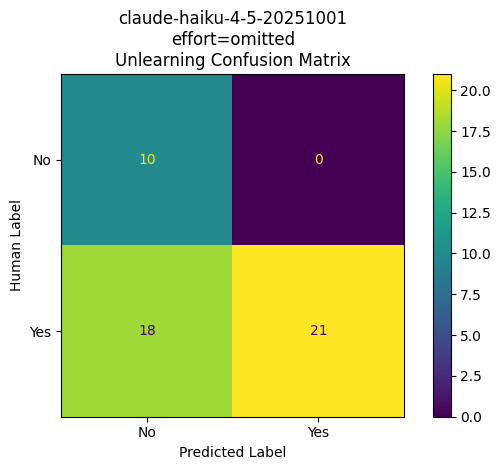

Provider: anthropic
Model: claude-sonnet-5
Configuration: effort=low
Scored rows: 49

True Negatives  (TN): 10
False Positives (FP): 0
False Negatives (FN): 25
True Positives  (TP): 14



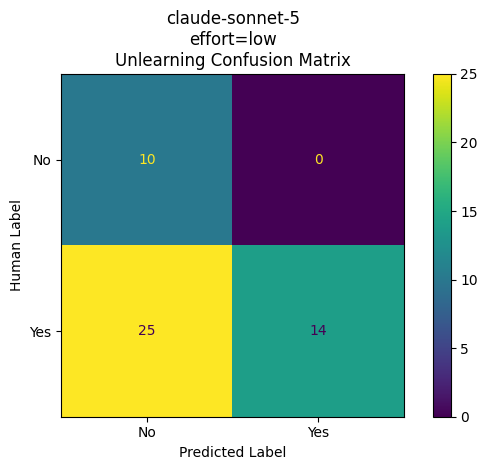

Provider: gemini
Model: gemini-3.1-flash-lite
Configuration: thinking_level=minimal
Scored rows: 49

True Negatives  (TN): 9
False Positives (FP): 1
False Negatives (FN): 21
True Positives  (TP): 18



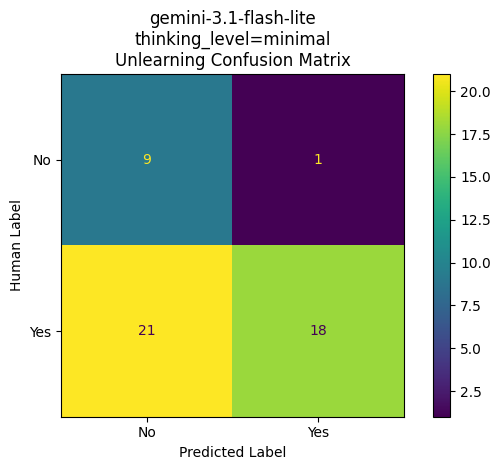

Provider: openai
Model: gpt-5.4
Configuration: reasoning_effort=low
Scored rows: 49

True Negatives  (TN): 10
False Positives (FP): 0
False Negatives (FN): 28
True Positives  (TP): 11



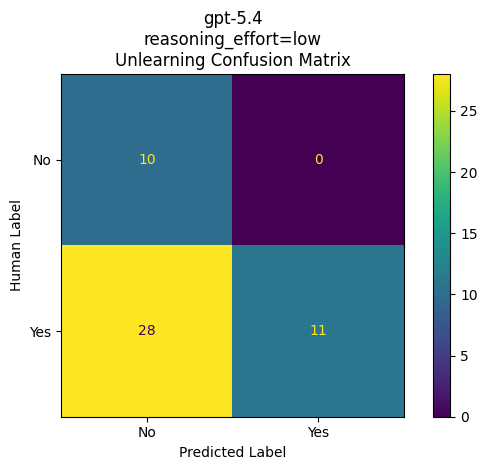

Provider: openai
Model: gpt-5.6-terra
Configuration: reasoning_effort=low
Scored rows: 49

True Negatives  (TN): 10
False Positives (FP): 0
False Negatives (FN): 30
True Positives  (TP): 9



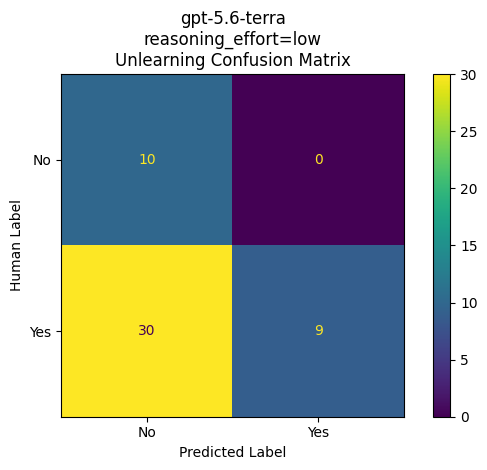

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Use only successful model responses.
cm_df = results_df[
    results_df["status"].eq("ok")
].copy()

# Normalize human and predicted Yes/No labels.
cm_df["y_true"] = cm_df[
    "ground_truth_unlearning"
].apply(normalize_yes_no)

cm_df["y_pred"] = cm_df[
    "pred_unlearning"
].apply(normalize_yes_no)

# Remove rows with missing/invalid labels.
cm_df = cm_df.dropna(
    subset=["y_true", "y_pred"]
).copy()


# Generate one confusion matrix for each model/configuration.
group_columns = [
    "provider",
    "model",
    "model_effort",
]

for group_values, model_df in cm_df.groupby(
    group_columns,
    dropna=False,
):
    provider, model, model_effort = group_values

    y_true = model_df["y_true"]
    y_pred = model_df["y_pred"]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=["No", "Yes"],
    )

    tn, fp, fn, tp = cm.ravel()

    print("=" * 70)
    print(f"Provider: {provider}")
    print(f"Model: {model}")
    print(f"Configuration: {model_effort}")
    print(f"Scored rows: {len(model_df)}")
    print()
    print(f"True Negatives  (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives  (TP): {tp}")
    print()

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No", "Yes"],
    )

    disp.plot(
        values_format="d",
    )

    plt.title(
        f"{model}\n"
        f"{model_effort}\n"
        f"Unlearning Confusion Matrix"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Human Label")
    plt.tight_layout()
    plt.show()

## 11. Save combined outputs

In [ ]:
PREDICTIONS_CSV = OUTPUT_DIR / f"predictions_long_{PROMPT_VERSION}.csv"
METRICS_CSV = OUTPUT_DIR / f"metrics_by_model_prompt_{PROMPT_VERSION}.csv"
USAGE_VARIANT_CSV = OUTPUT_DIR / f"usage_by_variant_{PROMPT_VERSION}.csv"
USAGE_MODEL_CSV = OUTPUT_DIR / f"usage_by_model_{PROMPT_VERSION}.csv"
PROMPT_AUDIT_CSV = OUTPUT_DIR / f"prompt_audit_{PROMPT_VERSION}.csv"
OUTPUT_XLSX = OUTPUT_DIR / f"unlearning_definitions_only_results_{PROMPT_VERSION}.xlsx"

results_df.to_csv(PREDICTIONS_CSV, index=False)
metrics_df.to_csv(METRICS_CSV, index=False)
usage_by_variant_df.to_csv(USAGE_VARIANT_CSV, index=False)
usage_by_model_df.to_csv(USAGE_MODEL_CSV, index=False)
prompt_audit_df.to_csv(PROMPT_AUDIT_CSV, index=False)

estimate_df = estimate_full_grid(
    test_df,
    active_model_configs(require_api_key=False),
    PROMPT_VARIANTS_TO_RUN,
)

import json
import numpy as np
import pandas as pd
import xlsxwriter


def excel_safe_value(value):
    """Convert pandas/numpy values into XlsxWriter-safe values."""

    if value is None:
        return None

    # Avoid pd.isna() on lists/dicts.
    if isinstance(value, (list, dict, tuple, set)):
        return json.dumps(
            value,
            ensure_ascii=False,
            default=str,
        )

    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, pd.Timestamp):
        return value.to_pydatetime()

    return value


def write_dataframe_to_sheet(
    workbook,
    df,
    sheet_name,
):
    worksheet = workbook.add_worksheet(sheet_name)

    header_format = workbook.add_format({
        "bold": True,
        "text_wrap": True,
        "valign": "top",
    })

    cell_format = workbook.add_format({
        "text_wrap": True,
        "valign": "top",
    })

    # Write column names.
    for col_index, column_name in enumerate(df.columns):
        worksheet.write(
            0,
            col_index,
            str(column_name),
            header_format,
        )

    # Write dataframe rows.
    for row_index, row in enumerate(
        df.itertuples(index=False, name=None),
        start=1,
    ):
        for col_index, value in enumerate(row):
            worksheet.write(
                row_index,
                col_index,
                excel_safe_value(value),
                cell_format,
            )

    # Freeze header row.
    worksheet.freeze_panes(1, 0)

    # Basic readable column widths.
    for col_index, column_name in enumerate(df.columns):
        column_text = str(column_name)

        sample_values = (
            df[column_name]
            .head(100)
            .fillna("")
            .astype(str)
        )

        max_length = max(
            [len(column_text)]
            + [
                min(len(value), 60)
                for value in sample_values
            ]
        )

        worksheet.set_column(
            col_index,
            col_index,
            min(max(max_length + 2, 12), 60),
        )


with xlsxwriter.Workbook(
    str(OUTPUT_XLSX)
) as workbook:

    write_dataframe_to_sheet(
        workbook,
        results_df,
        "Predictions_Long",
    )

    write_dataframe_to_sheet(
        workbook,
        metrics_df,
        "Metrics",
    )

    write_dataframe_to_sheet(
        workbook,
        usage_by_variant_df,
        "Usage_By_Variant",
    )

    write_dataframe_to_sheet(
        workbook,
        usage_by_model_df,
        "Usage_By_Model",
    )

    write_dataframe_to_sheet(
        workbook,
        estimate_df,
        "Preflight_Estimates",
    )

    write_dataframe_to_sheet(
        workbook,
        prompt_audit_df,
        "Prompt_Audit",
    )

print("Excel workbook saved:")
print(OUTPUT_XLSX)

print("Saved combined outputs:")
for path in [
    PREDICTIONS_CSV,
    METRICS_CSV,
    USAGE_VARIANT_CSV,
    USAGE_MODEL_CSV,
    PROMPT_AUDIT_CSV,
    OUTPUT_XLSX,
]:
    print("-", path)

print("\nProvider-specific snapshots:")
for provider in ["openai", "anthropic", "gemini"]:
    print("-", provider_predictions_csv(provider))
    print("-", provider_results_jsonl(provider))


Excel workbook saved:
outputs_unlearning_definitions_only_v5/unlearning_definitions_only_results_v5_definitions_only_combined_human_test.xlsx
Saved combined outputs:
- outputs_unlearning_definitions_only_v5/predictions_long_v5_definitions_only_combined_human_test.csv
- outputs_unlearning_definitions_only_v5/metrics_by_model_prompt_v5_definitions_only_combined_human_test.csv
- outputs_unlearning_definitions_only_v5/usage_by_variant_v5_definitions_only_combined_human_test.csv
- outputs_unlearning_definitions_only_v5/usage_by_model_v5_definitions_only_combined_human_test.csv
- outputs_unlearning_definitions_only_v5/prompt_audit_v5_definitions_only_combined_human_test.csv
- outputs_unlearning_definitions_only_v5/unlearning_definitions_only_results_v5_definitions_only_combined_human_test.xlsx

Provider-specific snapshots:
- outputs_unlearning_definitions_only_v5/openai_predictions_v5_definitions_only_combined_human_test.csv
- outputs_unlearning_definitions_only_v5/openai_raw_results_v5_defi

/tmp/ipykernel_614/1107091553.py:105: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna("")


## 12. Inspect binary disagreements and provider failures

In [ ]:
if "correct" in results_df.columns:
    disagreements = results_df[
        (results_df["status"] == "ok") & (results_df["correct"] == False)
    ].copy()

    parse_failures = results_df[
        results_df["status"].isin(["parse_failed", "error"])
    ].copy()

    print("Disagreements:", len(disagreements))
    display(disagreements[[
        "provider", "model", "model_effort", "prompt_variant", "row_id",
        "ground_truth_unlearning", "pred_unlearning", "pred_target_type",
        "pred_agency", "confidence", "rationale", "text_content",
    ]].head(50))

    print("Parse/API failures:", len(parse_failures))
    display(parse_failures[[
        "provider", "model", "model_effort", "prompt_variant", "row_id",
        "attempt_number", "status", "parse_error", "raw_response",
    ]].head(50))
else:
    print("No scored results yet. Run at least one provider section.")


## 13. Current experiment definition

- Input sheets: `GPT Test` and `Codebook` only.
- Prompt condition: `definitions_only` only.
- The codebook's own `Examples` column remains part of the definitions context.
- No separate labeled examples are supplied to the models.
- OpenAI, Anthropic, and Gemini use the same semantic prompt and shared output schema, with provider-native structured-output APIs.
- Provider runs remain separate for diagnosis and resume.
- Human `Target` and `Government Agency` values from the workbook are retained in output records but are not yet scored in this version.
